In [1]:
from glob import glob
import seaborn as sns
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.collections as mcoll
from config import *
import re
from itertools import combinations
from adjustText import adjust_text
import statsmodels.api as sm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(
    context='paper',
    style='ticks',
    palette='muted',
    font='sans-serif',
    font_scale=2,
    rc={'figure.figsize':(10, 6)}
)

In [2]:
K_MIN = 1
env_df = pd.read_csv('data/ale_envs.csv', index_col=0)
substrate_symbols = substrate_symbols | {'ammonium':r'NH$_4$'}

In [3]:
def calc_scores(ra_dfs, title, output_dir='output', n_mutations=100, same_desired_trait=True):
    max_dt = np.max([ra_df.loc['p_all', 'desired_trait'] for _, ra_df in ra_dfs])

    sample_stat_results = []
    results = []
    for env_id, ra_df in ra_dfs:
        ra_df.sort_values('n', inplace=True)
        
        ss_df = ra_df.groupby('n')['proxy_fitness'].count().to_frame().T.rename(index={'proxy_fitness': env_id})
        ss_df = ss_df.loc[:, [col for col in ss_df.columns if col <= n_mutations]]
        ss_df = ss_df[[col for col in ss_df.columns if col >= 0] + [col for col in ss_df.columns if col < 0]]
        ss_df = ss_df.drop(columns=[0])
        ss_df.columns = [f'n=={int(col)}' for col in ss_df.columns]
        ss_df["total_count"] = ss_df.sum(axis=1)
        sample_stat_results.append(ss_df)

        if same_desired_trait:
            dt_baseline = max_dt
        else:
            dt_baseline = ra_df.loc['p_all', 'desired_trait']
        ra_df['norm_pf'] = ra_df['proxy_fitness'] / ra_df.loc['a_all', 'proxy_fitness']
        ra_df['norm_dt'] = ra_df['desired_trait'] / dt_baseline
        ra_df['delta_pf'] = (ra_df['proxy_fitness'] - ra_df.loc['p_all', 'proxy_fitness']) / (ra_df.loc['a_all', 'proxy_fitness'] - ra_df.loc['p_all', 'proxy_fitness'])
        ra_df['delta_dt'] = (ra_df['desired_trait'] - ra_df.loc['p_all', 'desired_trait']) / (ra_df.loc['p_all', 'desired_trait'] - ra_df.loc['a_all', 'desired_trait'])
        ra_df['ddxdf'] = ra_df['delta_pf'] * ra_df['delta_dt']
        if len(ra_df) <= 2:
            robustness_score = 0
            tradeoff_score = 0
        else:
            robustness_score = ra_df.loc[ra_df['n'].between(K_MIN, n_mutations), 'norm_dt'].mean()
            tradeoff_score = ra_df.loc[ra_df['n'].between(K_MIN, n_mutations), 'ddxdf'].mean()
        results.append([env_id, robustness_score, tradeoff_score])

    sample_stat_res_df = pd.concat(sample_stat_results, axis=0).T
    sample_stat_res_df.to_csv(f"{output_dir}/{title.lower()}_sample_counts.csv")

    res_df = pd.DataFrame(results, columns=['env_id', 'robustness_score', 'trade-off_score']).set_index('env_id')
    res_df = res_df.join(env_df['nutrients'], how='left')[['nutrients', 'robustness_score', 'trade-off_score']]
    res_df.to_csv(f"{output_dir}/{title.lower()}_score_results.csv")
    return res_df

In [4]:
def plot_line(title, output_dir, df_all, x, y, hue, xlabel, ylabel, legend, colors=plt.get_cmap('tab20').colors, show_legend=True, inset_y=None, inset_y_label=None):
    ax = plt.gca()
    axins = None
    if inset_y:
        axins = inset_axes(ax, width='40%', height='40%', loc='upper center')
        axins.tick_params(axis='both', which='both', labelsize=16)
    
    sns.lineplot(x=df_all[x].astype(int), y=y, hue=hue, data=df_all, ax=ax, errorbar=("ci", 95), palette=colors)
    for c in ax.collections:
        if isinstance(c, mcoll.PolyCollection):
            c.set_alpha(0.1)
    if axins:
        g = sns.lineplot(x=df_all[x].astype(int), y=inset_y, hue=hue, data=df_all, ax=axins, errorbar=("ci", 95), palette=colors, legend=False)
        g.set_xlabel(None)
        g.set_ylabel(inset_y_label, fontsize=16)
        for c in axins.collections:
            if isinstance(c, mcoll.PolyCollection):
                c.set_alpha(0.1)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if show_legend:
        ax.legend([mpatches.Patch(color=c) for c in colors], df_all[legend].drop_duplicates(), fontsize=16)
    else:
        ax.legend().remove()
    if not os.path.exists(f'{output_dir}/figures/'):
        os.makedirs(f'{output_dir}/figures/')
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/figures/{title.lower()}_{y}_lineplot.png', bbox_inches='tight', dpi=300)
    plt.show()

In [5]:
def to_env_name(env_id):
    if env_id in env_df.index:
        nutrient_names = [substrate_symbols[nut] for nut in env_df.loc[env_id, 'nutrients'].split(', ')]
        nutrient_names = sorted(nutrient_names, key=lambda x: (0, x) if x in carbon_sources else (1, x))
        return f"{','.join(nutrient_names)}"
    else:
        return env_id
    

def to_latex(x, precision=3, mathmode=True):
    mantissa, exp = f"{x:.{precision-1}e}".split('e')
    exp = int(exp)
    s = f"{mantissa}\\times 10^{{{exp}}}"
    return f"${s}$" if mathmode else s


def show_results(title=None, input_dir=None, res_df=None, ra_dfs=None, env_list=None, n_mutations=100, same_desired_trait=True, colors=plt.get_cmap('tab20').colors):
    output_dir = os.path.dirname(input_dir) + '/'
    if title is None:
        title = os.path.basename(input_dir)
    if ra_dfs is None or res_df is None:
        ra_dfs = [(re.search(r"(\w+)_ra\w+", f).group(1).capitalize(), pd.read_csv(f, index_col=0, dtype={"n":"int"})) for f in glob(f'{input_dir}/*_ra_results.csv')]
        res_df = calc_scores(ra_dfs, title, output_dir, n_mutations, same_desired_trait)
    if env_list:
        ra_dfs = [(to_env_name(env_id), ra_df[ra_df['n'].between(K_MIN, n_mutations)]) for env_id, ra_df in ra_dfs]
        df_all = pd.concat([ra_df.assign(env_name=env_name) for env_name, ra_df in ra_dfs], ignore_index=True)
        env_name_list = [to_env_name(env_id) for env_id, _ in res_df.loc[env_list, :].iterrows()]
        env_list, env_name_list = zip(*sorted(list(zip(env_list, env_name_list)), key=lambda x: x[1]))
        df_all = df_all[df_all["env_name"].isin(env_name_list)].sort_values("env_name")
        print([f"{to_env_name(env_id)} ({env_id}) (RS = {to_latex(row['robustness_score'])}, TS = ${row['trade-off_score']:.3f}$)" for env_id, row in res_df.loc[env_list, ["robustness_score", "trade-off_score"]].iterrows()])        
        plot_line(title, output_dir, df_all, "n", "norm_dt", "env_name", "Number of changes in enzyme usage", "Desired trait (normalized)", "env_name", colors, True, "norm_pf", "Fitness (normalized)")
        plot_line(title, output_dir, df_all, "n", "ddxdf", "env_name", "Number of changes in enzyme usage", "Δdesired trait \u00D7 Δfitness (normalized)", "env_name", colors, False)
    return res_df, ra_dfs

# 1 Pigment

## 1.1 Experimental results (Kakko von Koch et al., 2025)

In [6]:
pigment_names = ['Bikaverin', 'Indigoidine']
pigment_colors = ['#B52A5C', '#2D3E90']

In [7]:
def plot_experimental_results(pigment_names, colors, medium_name, input_dir='data/pigment_exp_results', output_dir='results/pigment/figures'):
    for i, pigment_name in enumerate(pigment_names):
        data = pd.read_csv(f'{input_dir}/{pigment_name.lower()}_{medium_name.lower()}.csv')

        replicate_columns = ['Replicate Producing 1', 'Replicate Producing 2', 'Replicate Producing 3', 'Replicate Producing 4']
        data['Mean'] = data[replicate_columns].mean(axis=1)
        data['StdError'] = data[replicate_columns].sem(axis=1)

        x = data['Transfer'].values.reshape(-1, 1)
        y = data['Mean'].values
        error = data['StdError'].values
        color = colors[i % len(colors)]

        plt.errorbar(x, y, yerr=error, fmt='o', elinewidth=2, capsize=5, color=color, label=pigment_name.capitalize())
        plt.plot(x, y, linestyle='-', color=color, linewidth=1.5)

    plt.xlabel('Transfer')
    plt.ylabel('Replicate Producing %')
    plt.legend([mpatches.Patch(color=c) for c in colors], pigment_names, fontsize=16)

    plt.tight_layout()
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    plt.savefig(f'{output_dir}/{medium_name.lower()}_exp_results.png', bbox_inches='tight', dpi=300)
    plt.show()

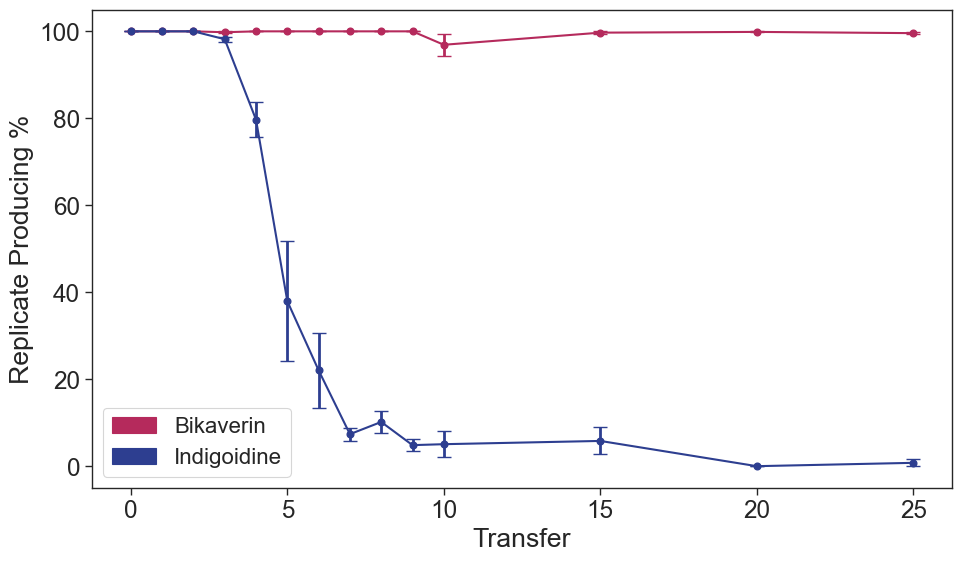

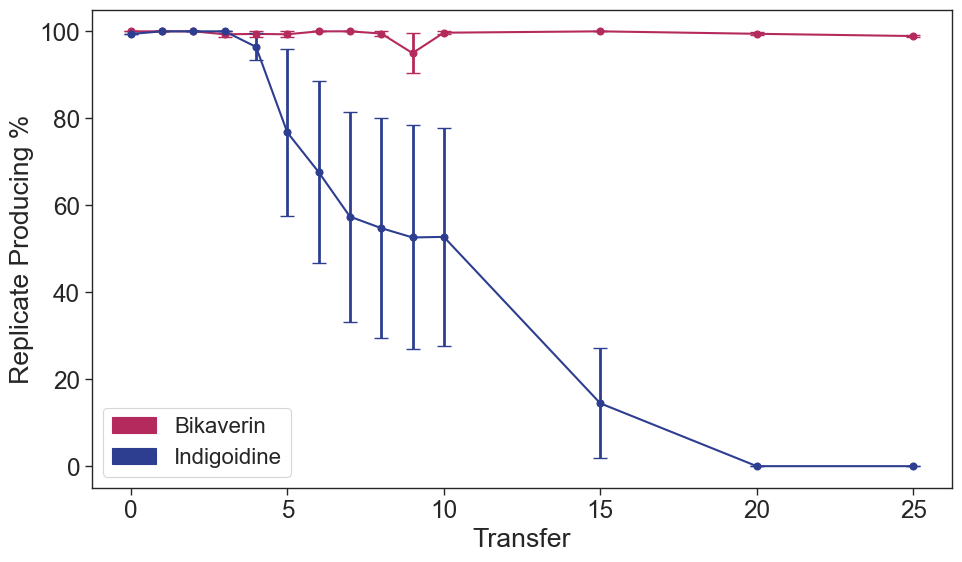

In [8]:
plot_experimental_results(pigment_names, pigment_colors, 'YNB')
plot_experimental_results(pigment_names, pigment_colors, 'YP')

## 1.2 Predictive results

['Bikaverin (Bikaverin) (RS = $4.61\\times 10^{-2}$, TS = $-0.850$)', 'Indigoidine (Indigoidine) (RS = $2.12\\times 10^{-2}$, TS = $-0.807$)']


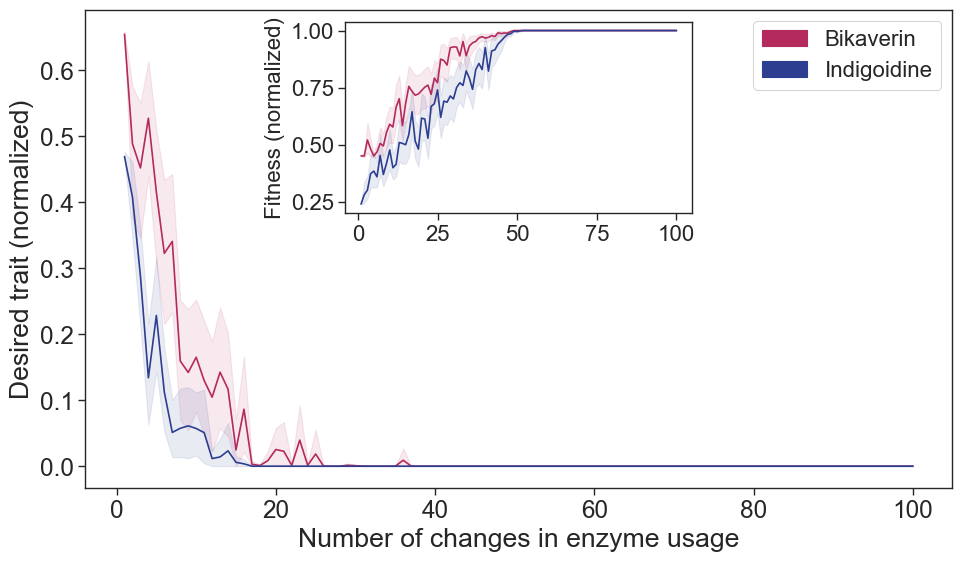

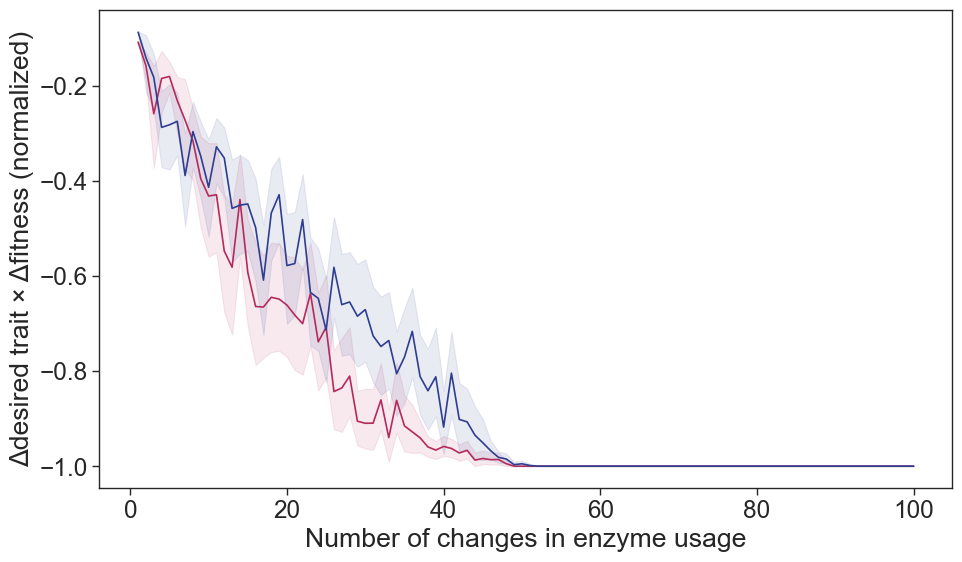

In [9]:
_ = show_results(input_dir="results/pigment/YNB", env_list=pigment_names, colors=pigment_colors, n_mutations=100, same_desired_trait=False)

['Bikaverin (Bikaverin) (RS = $5.33\\times 10^{-2}$, TS = $-0.252$)', 'Indigoidine (Indigoidine) (RS = $3.22\\times 10^{-3}$, TS = $-0.352$)']


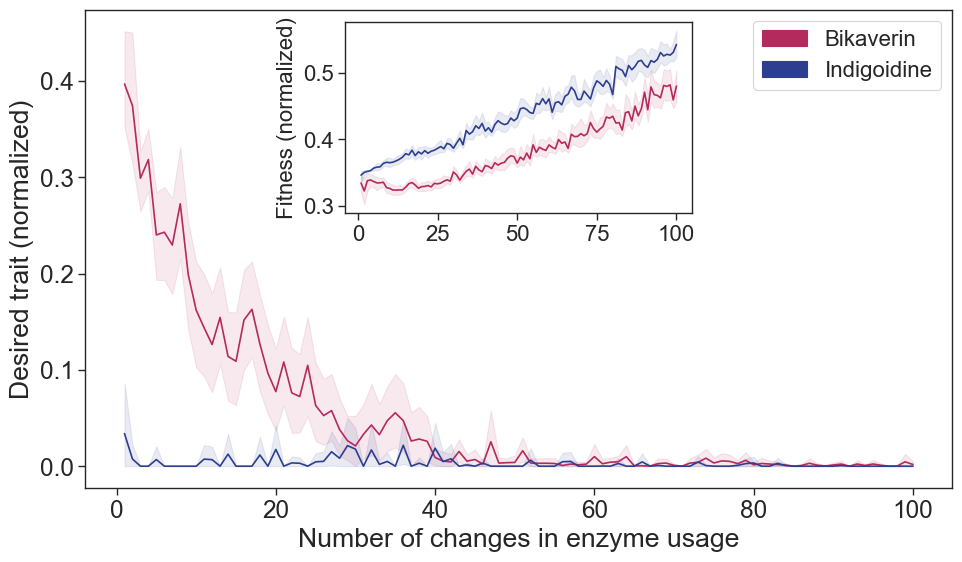

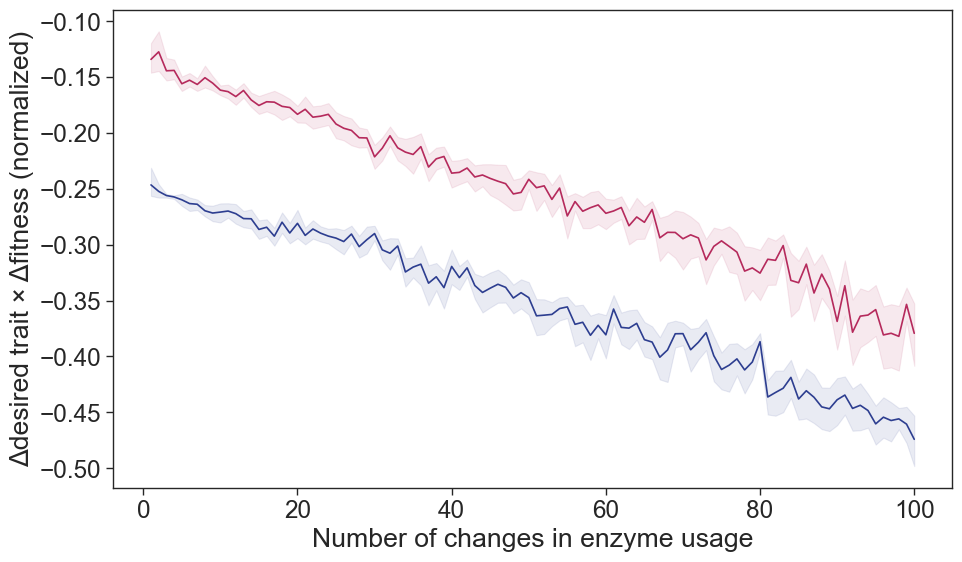

In [10]:
_ = show_results(input_dir="results/pigment/YP", env_list=pigment_names, colors=pigment_colors, n_mutations=100, same_desired_trait=False)

# 2 Aromatic

In [11]:
def enumerate_env_list(res_df, top=0.05, random_state=0):
    res_df = res_df.nlargest(int(len(res_df)*top), "robustness_score")
    res_df["bin"] = pd.qcut(res_df["trade-off_score"], q=10, duplicates='drop')
    env_list = sorted(res_df.groupby("bin", group_keys=False).apply(lambda x: x.sample(1, random_state=random_state)).index.tolist())
    return env_list

## 2.1 Predictive results

### 2.1.1 PEA

In [12]:
pea_res_df, pea_ra_dfs = show_results(input_dir="results/aromatic/PEA_ana", n_mutations=100)
print(f"{len(pea_res_df[(pea_res_df['robustness_score'] > 0)&(pea_res_df['trade-off_score'] < 0)])}/{len(pea_res_df)} strains can produce PEA against perturbations in appl env.")

401/1171 strains can produce PEA against perturbations in appl env.


['Asp,Met,Trp (Env_0641) (RS = $1.93\\times 10^{-2}$, TS = $-0.671$)', 'Gal,Arg,Gly (Env_0036) (RS = $1.88\\times 10^{-2}$, TS = $-0.680$)', 'Gal,Asn,Lys (Env_0053) (RS = $1.90\\times 10^{-2}$, TS = $-0.661$)', 'Gal,Gol,Asn (Env_0168) (RS = $2.24\\times 10^{-2}$, TS = $-0.616$)', 'Gal,Lys,Phe (Env_0124) (RS = $6.61\\times 10^{-2}$, TS = $-0.841$)', 'Glc,Met,Phe (Env_0295) (RS = $6.77\\times 10^{-2}$, TS = $-0.831$)', 'Gol,Asp,Ile (Env_1087) (RS = $2.03\\times 10^{-2}$, TS = $-0.640$)', 'Gol,Asp,Trp (Env_1094) (RS = $1.79\\times 10^{-2}$, TS = $-0.671$)', 'Gol,Lys,NH$_4$ (Env_0940) (RS = $1.81\\times 10^{-2}$, TS = $-0.699$)', 'Gol,Met,Phe (Env_1152) (RS = $6.19\\times 10^{-2}$, TS = $-0.854$)']


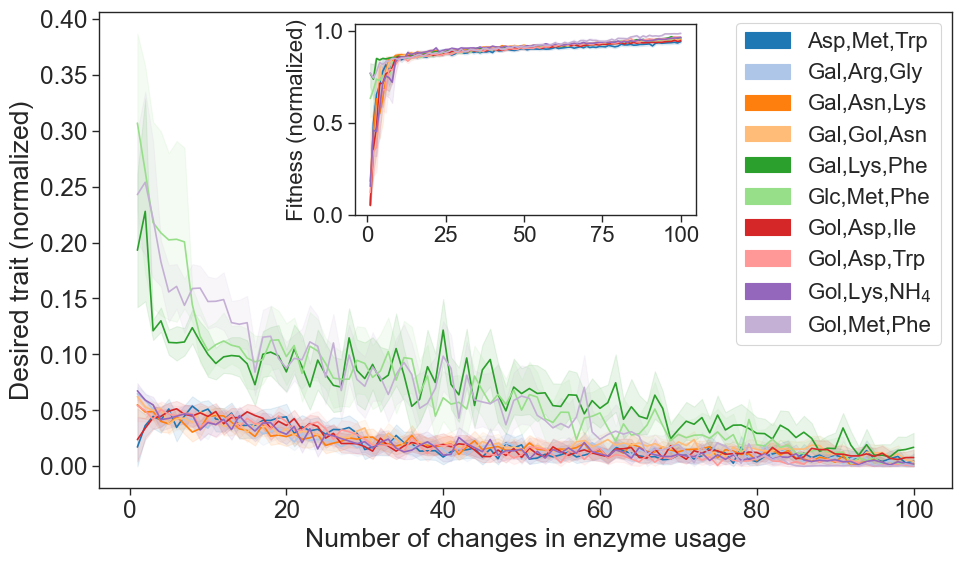

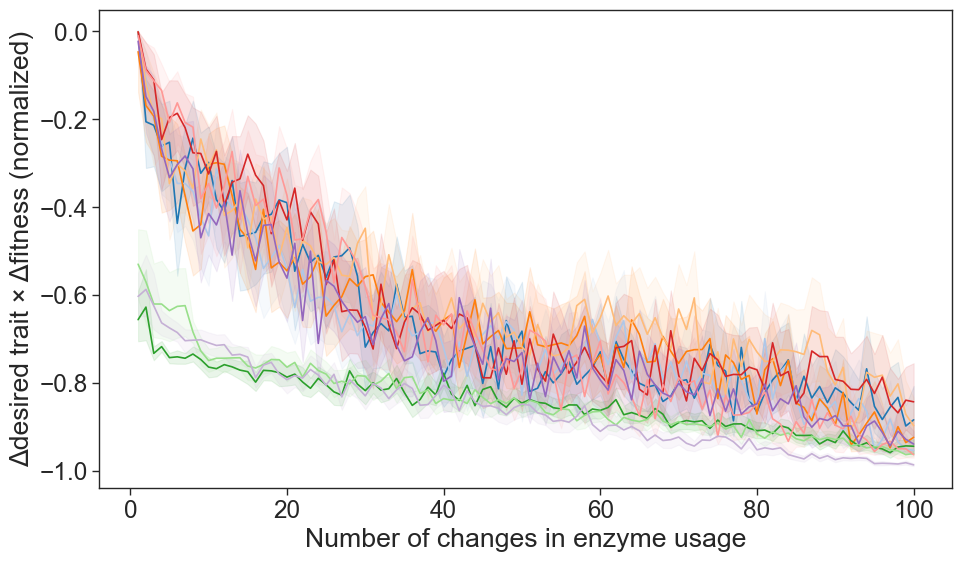

In [13]:
pea_list = enumerate_env_list(pea_res_df, top=0.05, random_state=19)
_ = show_results(input_dir="results/aromatic/PEA_ana", res_df=pea_res_df, ra_dfs=pea_ra_dfs, env_list=pea_list, n_mutations=100)

['Asp,Lys,Met (Env_0631) (RS = $1.53\\times 10^{-2}$, TS = $-0.723$)', 'Asp,Met,Trp (Env_0641) (RS = $1.93\\times 10^{-2}$, TS = $-0.671$)', 'EtOH,Asp,Leu (Env_0978) (RS = $1.60\\times 10^{-2}$, TS = $-0.701$)', 'EtOH,Gal,Arg (Env_0152) (RS = $1.64\\times 10^{-2}$, TS = $-0.713$)', 'Gal,Asn,Gly (Env_0050) (RS = $1.85\\times 10^{-2}$, TS = $-0.664$)', 'Gal,NH$_4$,Phe (Env_0873) (RS = $6.04\\times 10^{-2}$, TS = $-0.844$)', 'Gol,Asn,Asp (Env_1070) (RS = $1.54\\times 10^{-2}$, TS = $-0.690$)', 'Gol,Asp,Gly (Env_1086) (RS = $1.50\\times 10^{-2}$, TS = $-0.705$)', 'Gol,Asp,Ile (Env_1087) (RS = $2.03\\times 10^{-2}$, TS = $-0.640$)', 'Gol,Lys,NH$_4$ (Env_0940) (RS = $1.81\\times 10^{-2}$, TS = $-0.699$)']


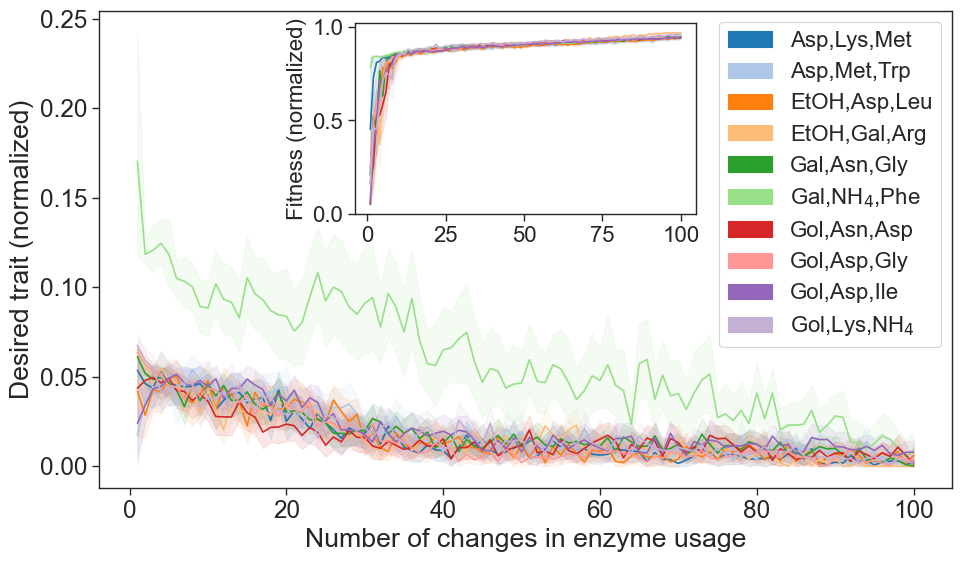

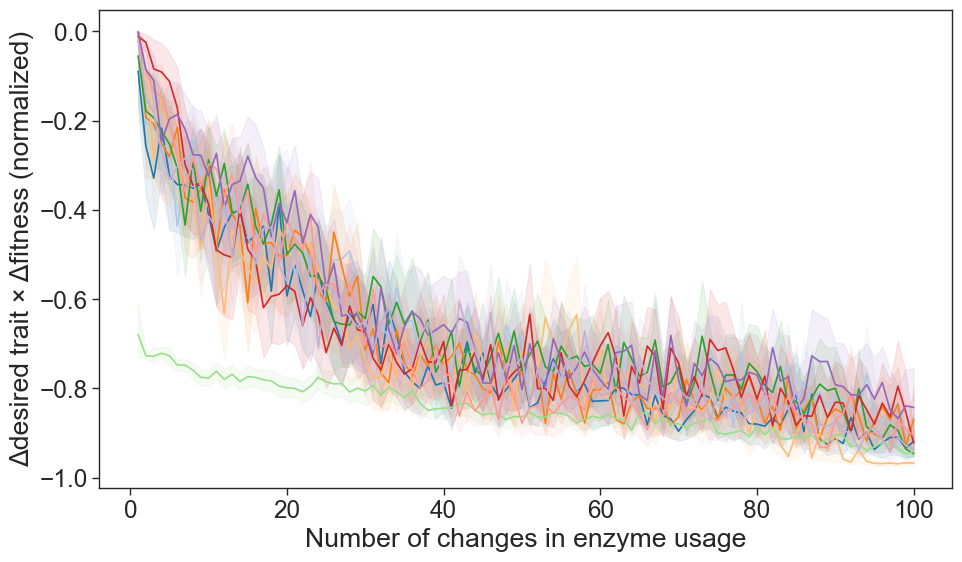

In [14]:
pea_list1 = enumerate_env_list(pea_res_df, top=0.1, random_state=19)
_ = show_results("PEA_ana_sup1", "results/aromatic/PEA_ana", res_df=pea_res_df, ra_dfs=pea_ra_dfs, env_list=pea_list1, n_mutations=100)

['Ala,Asp,Phe (Env_0373) (RS = $0.00\\times 10^{0}$, TS = $0.000$)', 'EtOH,Glc,Glu (Env_0320) (RS = $1.51\\times 10^{-2}$, TS = $-0.712$)', 'Gal,Gln,Gly (Env_0086) (RS = $1.61\\times 10^{-2}$, TS = $-0.688$)', 'Glc,Asn,Met (Env_0219) (RS = $1.08\\times 10^{-2}$, TS = $-0.769$)', 'Glc,Asn,Val (Env_0225) (RS = $1.22\\times 10^{-2}$, TS = $-0.738$)', 'Glc,Leu,Trp (Env_0286) (RS = $1.97\\times 10^{-3}$, TS = $-0.861$)', 'Gol,Asn,Leu (Env_1075) (RS = $1.39\\times 10^{-2}$, TS = $-0.716$)']


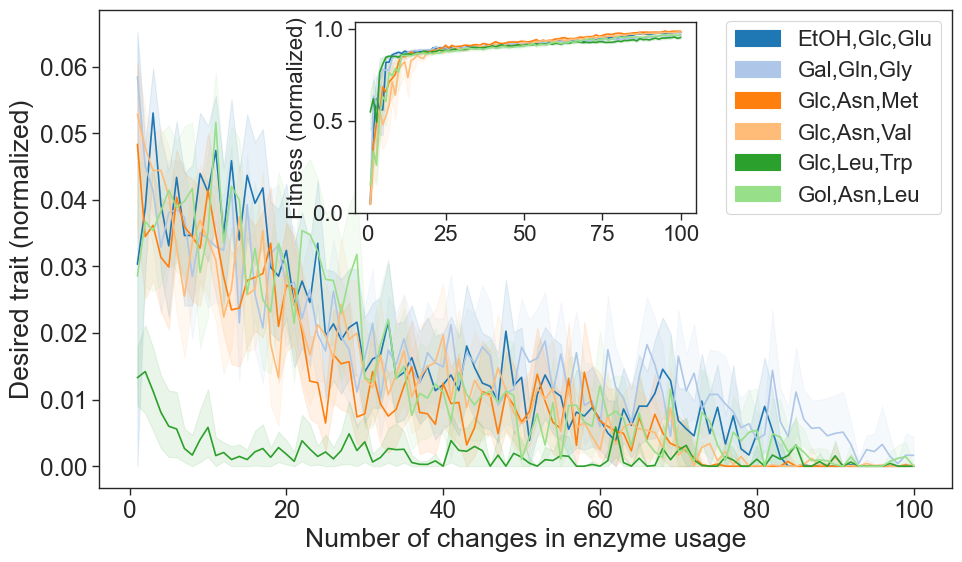

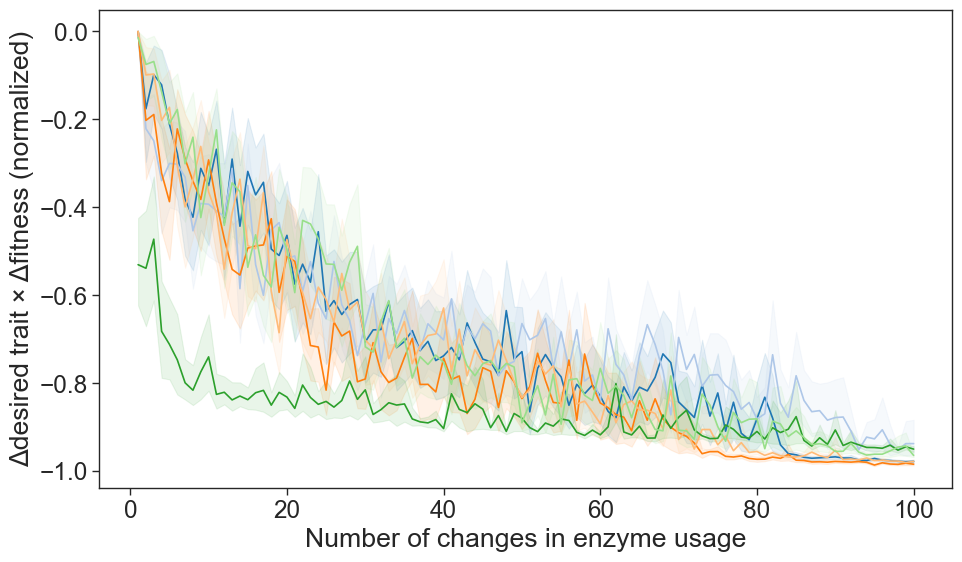

In [15]:
pea_list2 = enumerate_env_list(pea_res_df, top=0.5, random_state=19)
_ = show_results("PEA_ana_sup2", "results/aromatic/PEA_ana", res_df=pea_res_df, ra_dfs=pea_ra_dfs, env_list=pea_list2, n_mutations=100)

### 2.1.2 BCHA

In [16]:
bcha_res_df, bcha_ra_dfs = show_results(input_dir="results/aromatic/BCHA_ana", n_mutations=100)
print(f"{len(bcha_res_df[(bcha_res_df['robustness_score'] > 0)&(bcha_res_df['trade-off_score'] < 0)])}/{len(bcha_res_df)} strains can produce BCHA against perturbations in appl env.")


1064/1171 strains can produce BCHA against perturbations in appl env.


['Arg,Asp,Lys (Env_0440) (RS = $2.65\\times 10^{-2}$, TS = $-0.690$)', 'Arg,NH$_4$,Ser (Env_0903) (RS = $2.99\\times 10^{-2}$, TS = $-0.695$)', 'EtOH,Glc,Ser (Env_0326) (RS = $2.85\\times 10^{-2}$, TS = $-0.815$)', 'Gal,Glc,Ile (Env_0008) (RS = $5.94\\times 10^{-2}$, TS = $-0.831$)', 'Gal,Ile,Lys (Env_0108) (RS = $4.61\\times 10^{-2}$, TS = $-0.865$)', 'Glc,Ile,Val (Env_0280) (RS = $5.69\\times 10^{-2}$, TS = $-0.843$)', 'Glc,Leu,NH$_4$ (Env_0889) (RS = $5.41\\times 10^{-2}$, TS = $-0.836$)', 'Glc,Leu,Trp (Env_0286) (RS = $6.04\\times 10^{-2}$, TS = $-0.818$)', 'Gol,Ala,Phe (Env_1049) (RS = $2.64\\times 10^{-2}$, TS = $-0.660$)', 'Gol,Leu,Met (Env_1140) (RS = $5.20\\times 10^{-2}$, TS = $-0.838$)']


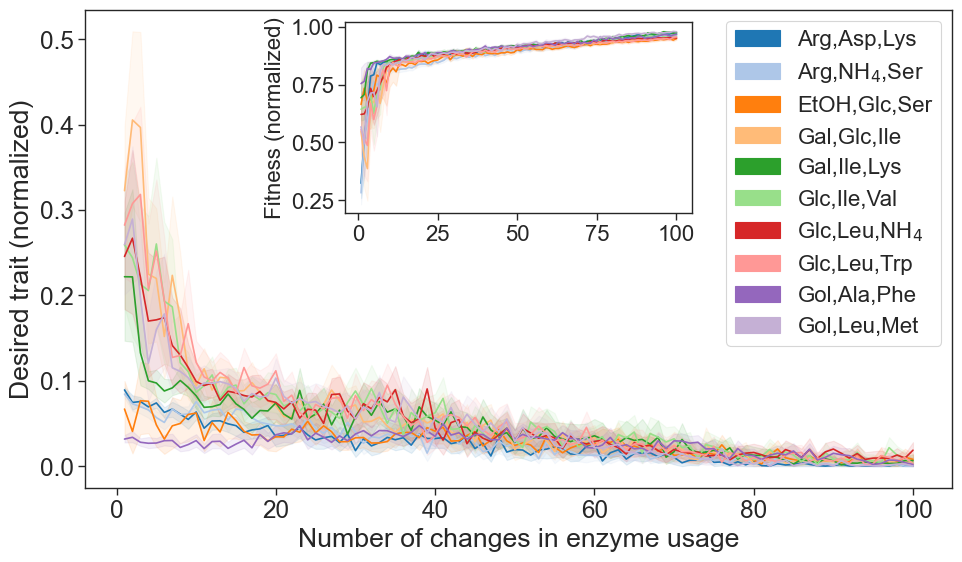

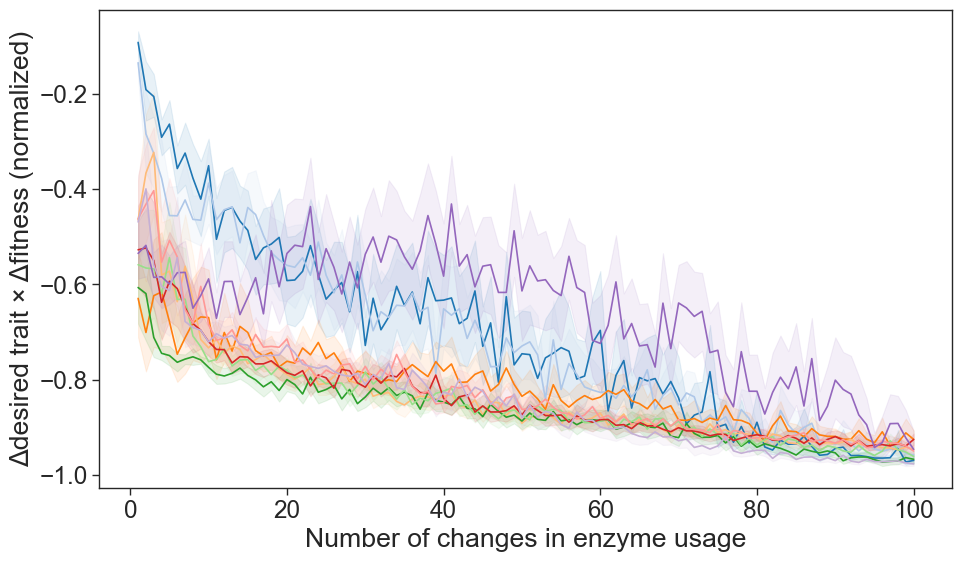

In [17]:
bcha_list = enumerate_env_list(bcha_res_df, top=0.05, random_state=10)
_ = show_results(input_dir="results/aromatic/BCHA_ana", res_df=bcha_res_df, ra_dfs=bcha_ra_dfs, env_list=bcha_list, n_mutations=100)

['Arg,Asp,Gln (Env_0436) (RS = $2.70\\times 10^{-2}$, TS = $-0.663$)', 'Arg,Gln,Gly (Env_0460) (RS = $2.50\\times 10^{-2}$, TS = $-0.709$)', 'Arg,Gln,Phe (Env_0465) (RS = $2.62\\times 10^{-2}$, TS = $-0.694$)', 'EtOH,Arg,Gln (Env_0957) (RS = $2.64\\times 10^{-2}$, TS = $-0.693$)', 'Gal,Gol,Leu (Env_0174) (RS = $5.74\\times 10^{-2}$, TS = $-0.840$)', 'Gal,Leu,NH$_4$ (Env_0870) (RS = $6.50\\times 10^{-2}$, TS = $-0.830$)', 'Glc,Ile,Trp (Env_0278) (RS = $5.34\\times 10^{-2}$, TS = $-0.804$)', 'Glc,Ile,Val (Env_0280) (RS = $5.69\\times 10^{-2}$, TS = $-0.843$)', 'Gol,Arg,Trp (Env_1067) (RS = $2.58\\times 10^{-2}$, TS = $-0.682$)', 'Gol,Ile,Phe (Env_1133) (RS = $2.71\\times 10^{-2}$, TS = $-0.740$)']


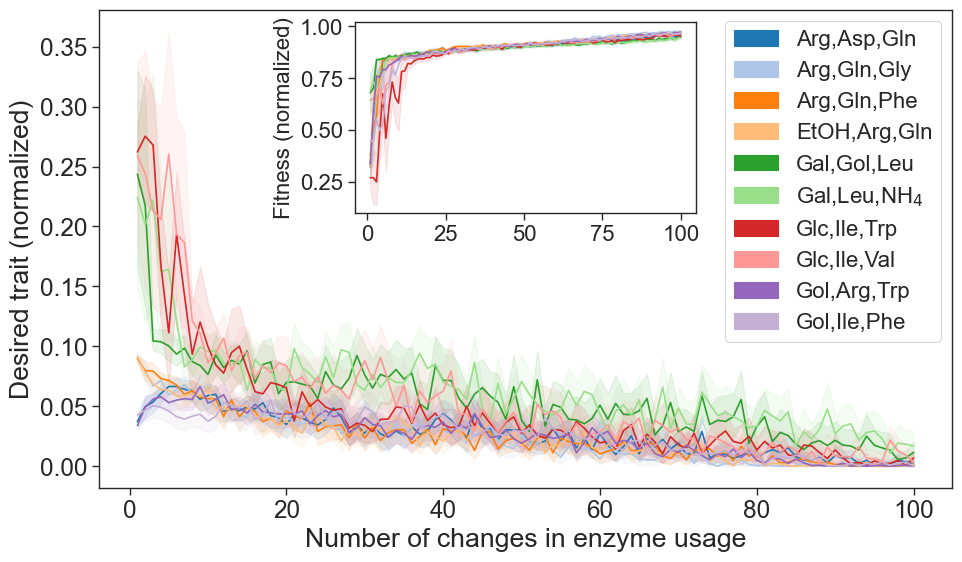

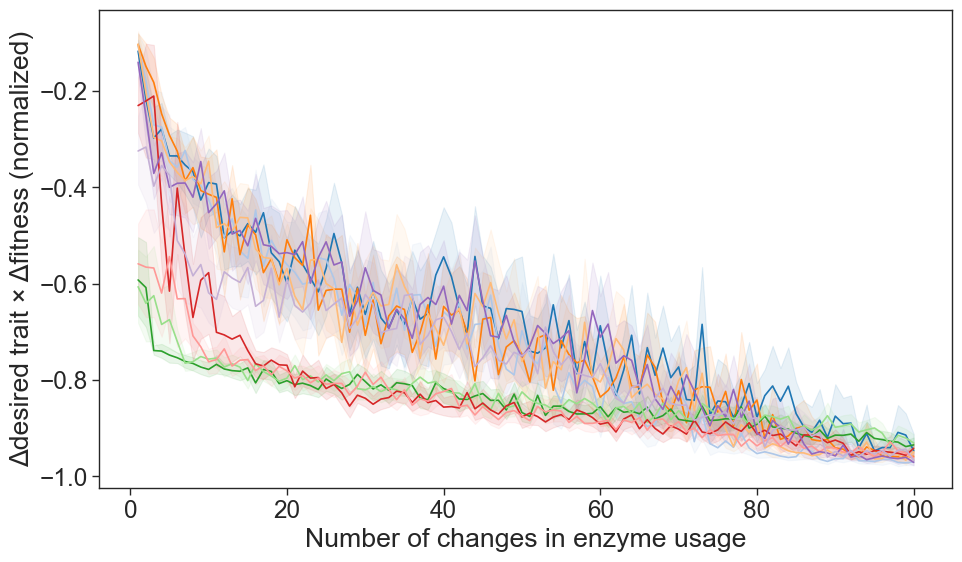

In [18]:
bcha_list1 = enumerate_env_list(bcha_res_df, top=0.1, random_state=10)
_ = show_results("BCHA_ana_sup1", "results/aromatic/BCHA_ana", res_df=bcha_res_df, ra_dfs=bcha_ra_dfs, env_list=bcha_list1, n_mutations=100)

['Asp,Glu,Leu (Env_0584) (RS = $1.78\\times 10^{-2}$, TS = $-0.724$)', 'Asp,Glu,Phe (Env_0587) (RS = $1.62\\times 10^{-2}$, TS = $-0.757$)', 'Gal,Glu,NH$_4$ (Env_0866) (RS = $1.86\\times 10^{-2}$, TS = $-0.695$)', 'Gal,Glu,Phe (Env_0080) (RS = $1.77\\times 10^{-2}$, TS = $-0.707$)', 'Gal,Gol,Glu (Env_0170) (RS = $1.94\\times 10^{-2}$, TS = $-0.672$)', 'Gal,Lys,Ser (Env_0125) (RS = $1.81\\times 10^{-2}$, TS = $-0.653$)', 'Gln,Gly,Leu (Env_0726) (RS = $1.76\\times 10^{-2}$, TS = $-0.797$)', 'Gln,Trp,Val (Env_0778) (RS = $1.88\\times 10^{-2}$, TS = $-0.768$)', 'Glu,Thr,Val (Env_0721) (RS = $1.70\\times 10^{-2}$, TS = $-0.745$)', 'Gol,Leu,Lys (Env_1139) (RS = $4.16\\times 10^{-2}$, TS = $-0.852$)']


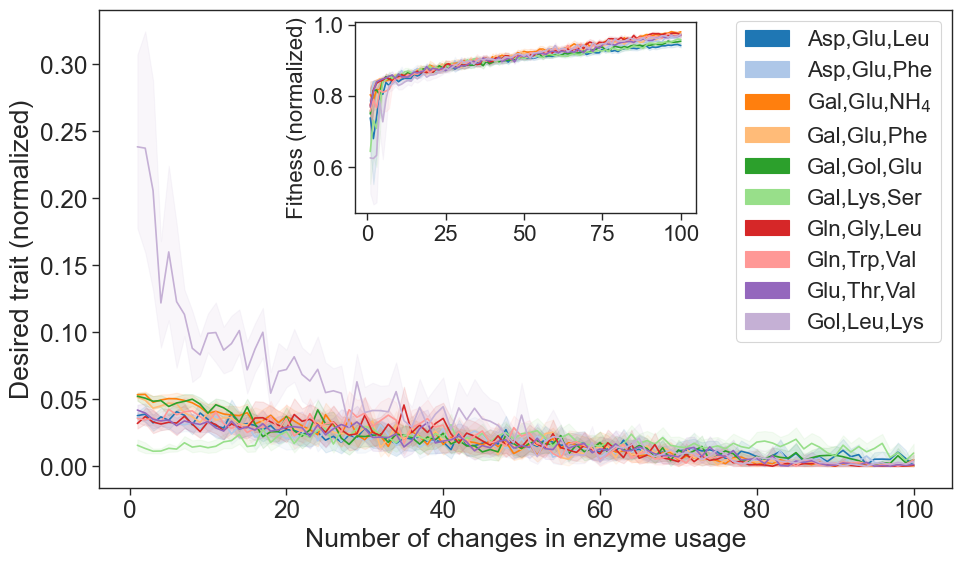

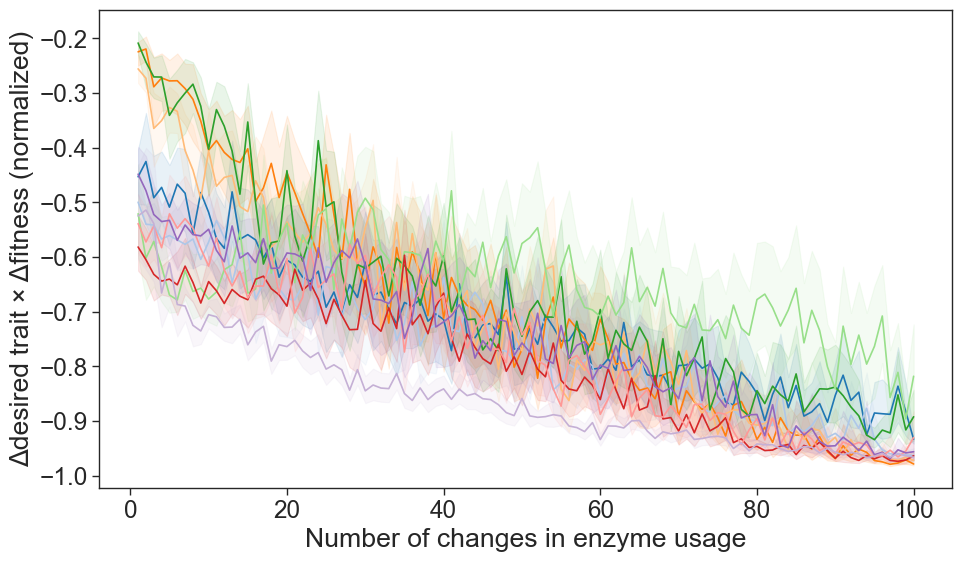

In [19]:
bcha_list2 = enumerate_env_list(bcha_res_df, top=0.5, random_state=10)
_ = show_results("BCHA_ana_sup2", "results/aromatic/BCHA_ana", res_df=bcha_res_df, ra_dfs=bcha_ra_dfs, env_list=bcha_list2, n_mutations=100)

## 2.2 Statistical analysis

In [20]:
def calculate_nutrient_effect(df, title, output_dir, pc1='robustness_score', pc2='trade-off_score'):
    df = df.reset_index()
    df['nutrients'] = df['nutrients'].apply(lambda x: [n.strip() for n in x.split(',')])

    y1 = (df[pc1] - df[pc1].mean()) / df[pc1].std()
    y2 = (df[pc2] - df[pc2].mean()) / df[pc2].std()

    all_nutrients = sorted(set(n for row in df['nutrients'] for n in row))
    nutrient_matrix = pd.DataFrame(df['nutrients'].apply(lambda ns: {n: 1 for n in ns}).tolist()).fillna(0).astype(int)
    nutrient_matrix = nutrient_matrix.reindex(columns=all_nutrients, fill_value=0)
    df = pd.concat([df, nutrient_matrix], axis=1)

    X_single = sm.add_constant(df[all_nutrients])
    model_r_single = sm.OLS(y1, X_single).fit()
    model_e_single = sm.OLS(y2, X_single).fit()

    res_single = pd.DataFrame({
        'nutrients': all_nutrients,
        'n_nutrients': [1] * len(all_nutrients),
        'envs': [df[df[n] == 1]['env_id'].tolist() for n in all_nutrients],
        f'{pc1}_wt': model_r_single.params.values[1:],
        f'{pc1}_pv': model_r_single.pvalues.values[1:],
        f'{pc2}_wt': model_e_single.params.values[1:],
        f'{pc2}_pv': model_e_single.pvalues.values[1:]
    })

    df['nutrient_pairs'] = df['nutrients'].apply(lambda x: [', '.join(sorted(pair)) for pair in combinations(x, 2)])
    all_pairs = sorted(set(pair for row in df['nutrient_pairs'] for pair in row))
    pair_matrix = pd.DataFrame(df['nutrient_pairs'].apply(lambda pairs: {pair: 1 for pair in pairs}).tolist()).fillna(0).astype(int)
    pair_matrix = pair_matrix.reindex(columns=all_pairs, fill_value=0)
    df = pd.concat([df, pair_matrix], axis=1)

    X_pairs = sm.add_constant(df[all_pairs])
    model_r_pair = sm.OLS(y1, X_pairs).fit()
    model_e_pair = sm.OLS(y2, X_pairs).fit()

    res_pair = pd.DataFrame({
        'nutrients': all_pairs,
        'n_nutrients': [2] * len(all_pairs),
        'envs': [df[df[p] == 1]['env_id'].tolist() for p in all_pairs],
        f'{pc1}_wt': model_r_pair.params.values[1:],
        f'{pc1}_pv': model_r_pair.pvalues.values[1:],
        f'{pc2}_wt': model_e_pair.params.values[1:],
        f'{pc2}_pv': model_e_pair.pvalues.values[1:]
    })

    res_df = pd.concat([res_single, res_pair], ignore_index=True).sort_values(by=['n_nutrients', 'nutrients'], ascending=[True, True]).reset_index(drop=True)
    res_df.to_csv(f"{output_dir}/{title.lower()}_nut_effect_on_{pc1}_{pc2}.csv", index=False)
    return res_df


In [21]:
def plot_nut_scatter(nut_df, n_nutrients, title, output_dir, pv=0.05, n_envs=5, abbr=True, pc1='robustness_score', pc2='trade-off_score'):
    nut_df = nut_df[nut_df['n_nutrients'] == n_nutrients]
    nut_df = nut_df[nut_df['envs'].apply(lambda x: len(x) >= n_envs)]
    nut_df = nut_df.sort_values(by=f'{pc1}_wt', ascending=False)
    r, p = pearsonr(nut_df[f'{pc1}_wt'], nut_df[f'{pc2}_wt'])

    mask = (nut_df[f'{pc1}_pv'] <= pv) & (nut_df[f'{pc2}_pv'] <= pv)
    nut_df['is_significant'] = mask

    ax = plt.gca()
    color_palette = dict(zip(
        nut_df['nutrients'],
        matplotlib.colormaps['Spectral'].resampled(len(nut_df))(range(len(nut_df)))
    ))

    sns.scatterplot(
        data=nut_df[~nut_df['is_significant']],
        x=f'{pc1}_wt',
        y=f'{pc2}_wt',
        size=nut_df[~nut_df['is_significant']]['envs'].apply(len),
        hue='nutrients',
        palette=color_palette,
        sizes=(10, 200),
        alpha=0.4,
        legend=False,
        ax=ax
    )

    sns.scatterplot(
        data=nut_df[nut_df['is_significant']],
        x=f'{pc1}_wt',
        y=f'{pc2}_wt',
        size=nut_df[nut_df['is_significant']]['envs'].apply(len),
        hue='nutrients',
        palette=color_palette,
        sizes=(10, 200),
        alpha=1.0,
        legend=False,
        ax=ax
    )

    ax.axhline(0, linestyle='--', color='gray', alpha=0.6)
    ax.axvline(0, linestyle='--', color='gray', alpha=0.6)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, frameon=False, title=f"r = {r:.3f}", title_fontsize=16)
    print(f"r = {r:.3f}, p = {p:.3f}")

    texts = []
    for _, row in nut_df[(nut_df['is_significant']) | (nut_df['n_nutrients'] == 1)].iterrows():
        label = ','.join(substrate_symbols[n.strip()] if abbr else n.strip().capitalize() for n in row['nutrients'].split(','))

        fontsize = 10 if row['n_nutrients'] == 1 else 8
        weight = 'bold'
        alpha = 1.0 if row['is_significant'] else 0.6

        texts.append(
            plt.text(
                row[f'{pc1}_wt'], row[f'{pc2}_wt'], label,
                fontsize=fontsize, weight=weight, alpha=alpha,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6, edgecolor='gray')
            )
        )

    adjust_text(
        texts,
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.4, shrinkA=2, shrinkB=2),
        force_text=1.0,
        force_points=0.5,
        expand_points=(2.0, 2.5),
        expand_text=(2.0, 2.5),
        only_move={'points': 'y', 'text': 'xy'},
        lim=1500
    )

    plt.xlabel(f"Effect on {' '.join([s[0].upper() + s[1:] for s in pc1.split('_')])}")
    plt.ylabel(f"Effect on {' '.join([s[0].upper() + s[1:] for s in pc2.split('_')])}")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()

    plt.savefig(f"{output_dir}/figures/{title.lower()}_nut_effect_scatterplot_on_{pc1}_{pc2}.png", bbox_inches='tight', dpi=300)
    plt.show()
    

### 2.2.1 PEA

r = -0.685, p = 0.000


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


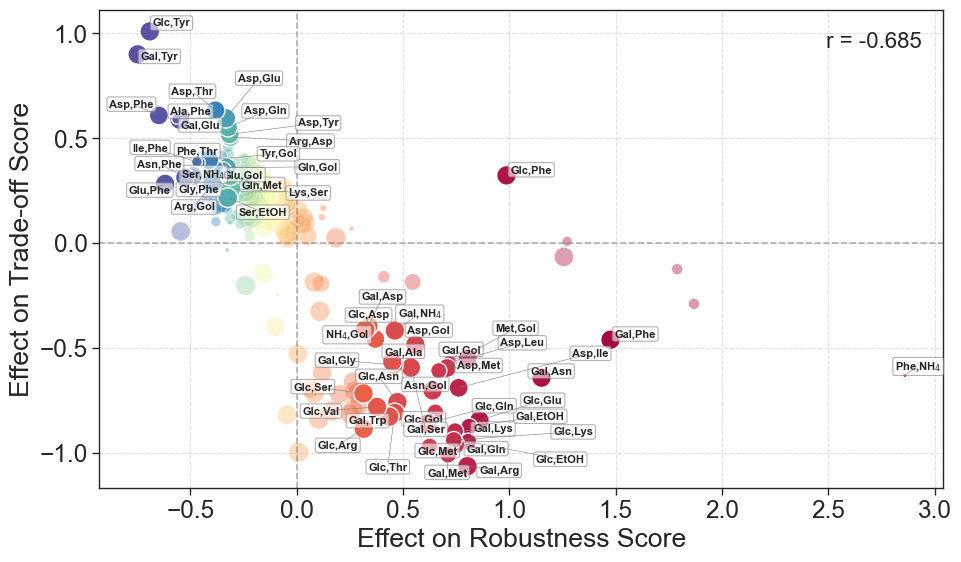

r = 0.055, p = 0.407


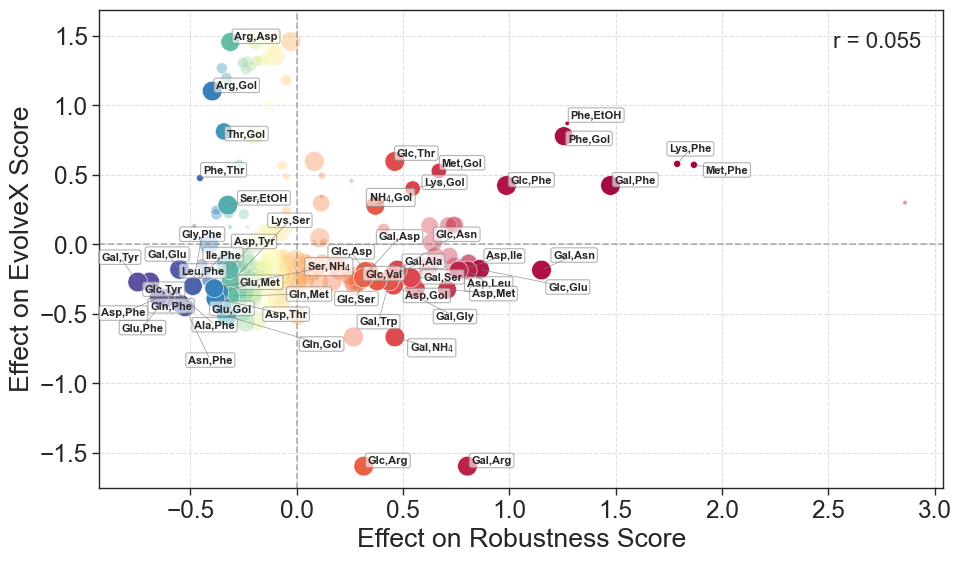

r = 0.152, p = 0.022


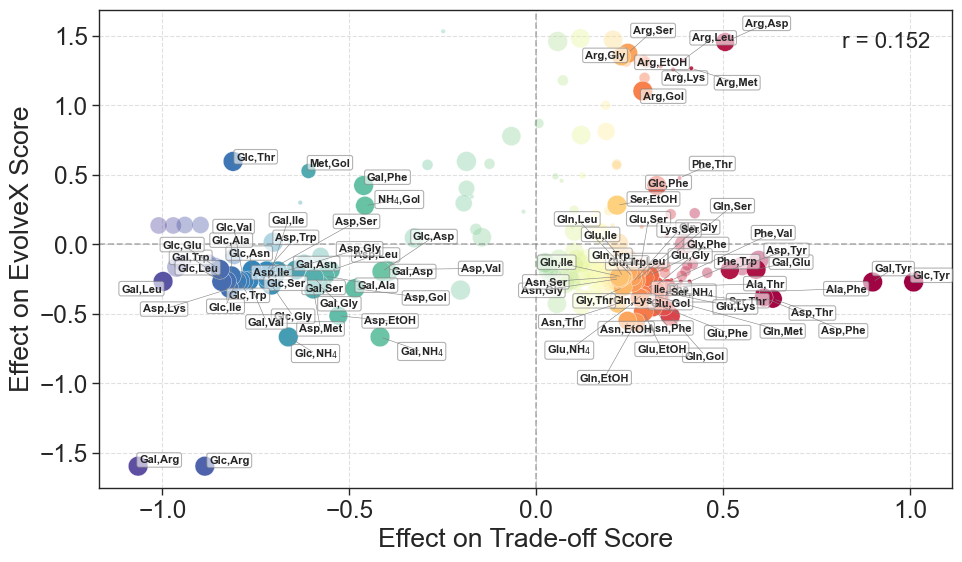

In [22]:
pea_nut_df = calculate_nutrient_effect(pea_res_df, 'PEA_ana', 'results/aromatic/', pc1='robustness_score', pc2='trade-off_score')
plot_nut_scatter(pea_nut_df, 2, 'PEA_ana', 'results/aromatic/', pc1='robustness_score', pc2='trade-off_score')

pea_evolvex_df = pea_res_df.join(env_df['EvolveX_score_PEA'], how='left')[['nutrients', 'EvolveX_score_PEA', 'robustness_score', 'trade-off_score']].rename(columns={'EvolveX_score_PEA':'evolveX_score'})
pea_evolvex_df['evolveX_score'] = pea_evolvex_df['evolveX_score'].max() - pea_evolvex_df['evolveX_score']
pea_evolvex_nut_df = calculate_nutrient_effect(pea_evolvex_df, 'PEA_ana', 'results/aromatic/', pc1='robustness_score', pc2='evolveX_score')
plot_nut_scatter(pea_evolvex_nut_df, 2, 'PEA_ana', 'results/aromatic/', pc1='robustness_score', pc2='evolveX_score')
pea_evolvex_nut_df2 = calculate_nutrient_effect(pea_evolvex_df, 'PEA_ana', 'results/aromatic/', pc1='trade-off_score', pc2='evolveX_score')
plot_nut_scatter(pea_evolvex_nut_df2, 2, 'PEA_ana', 'results/aromatic/', pc1='trade-off_score', pc2='evolveX_score')

### 2.2.2 BCHA

r = -0.550, p = 0.000


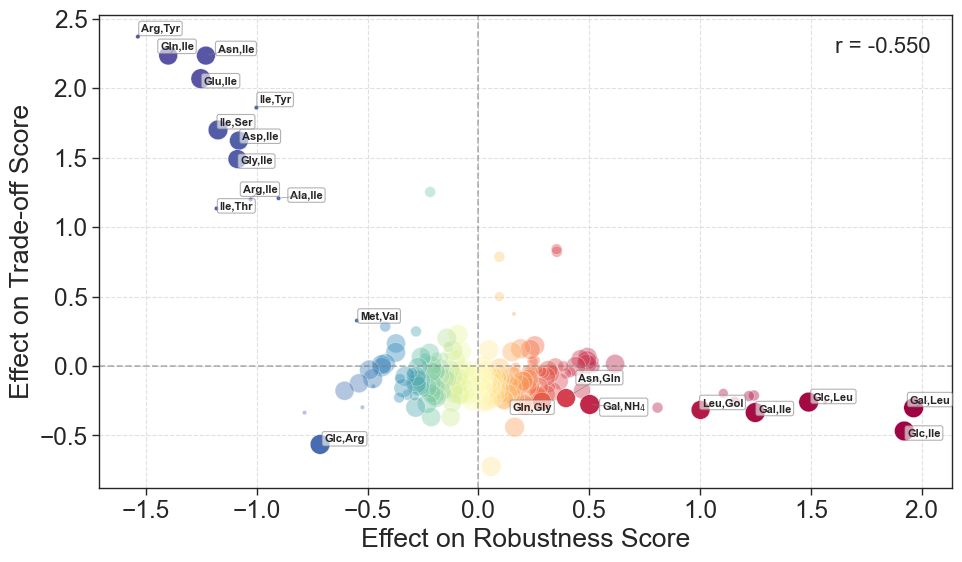

r = 0.014, p = 0.828


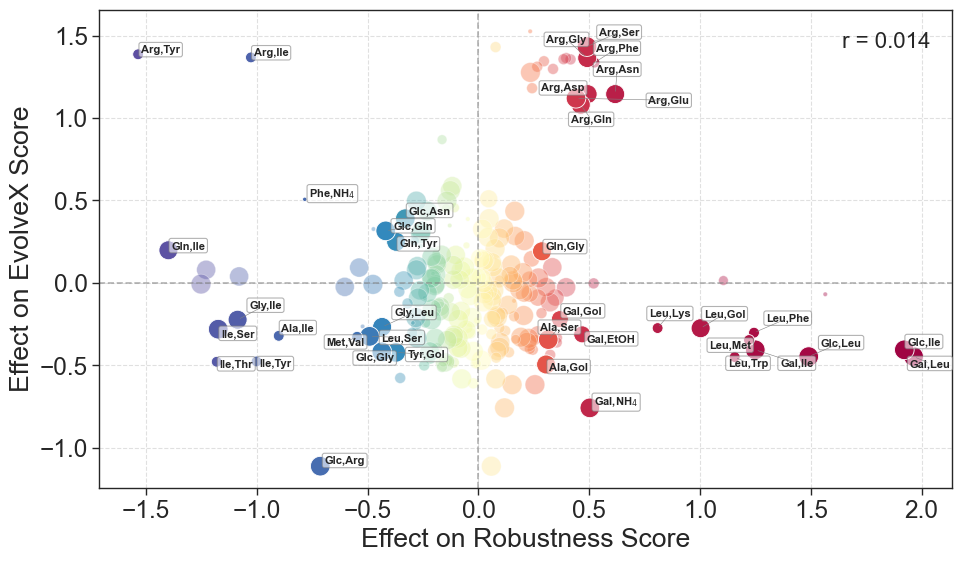

r = 0.073, p = 0.273


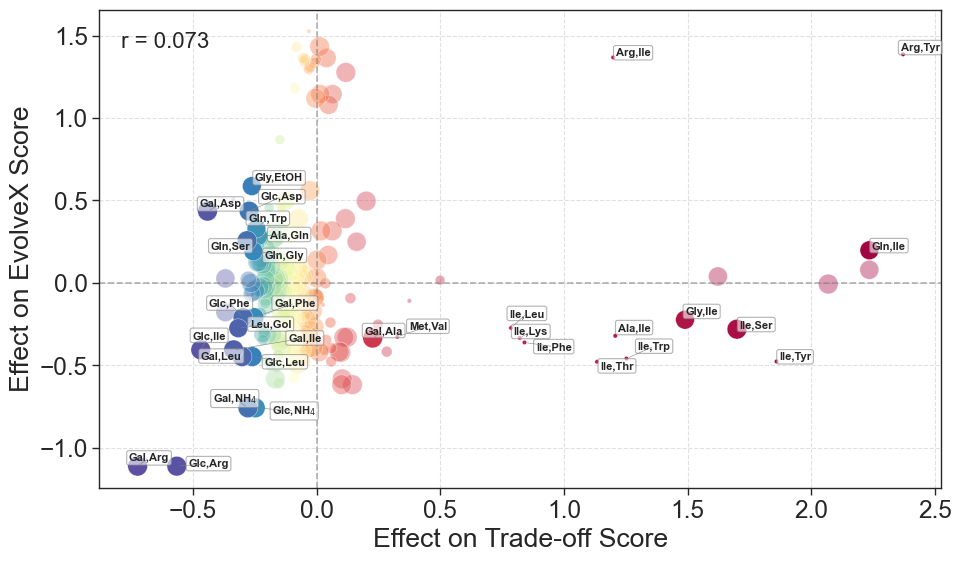

In [23]:
bcha_nut_df = calculate_nutrient_effect(bcha_res_df, 'BCHA_ana', 'results/aromatic/', pc1='robustness_score', pc2='trade-off_score')
plot_nut_scatter(bcha_nut_df, 2, 'BCHA_ana', 'results/aromatic/', pc1='robustness_score', pc2='trade-off_score')

bcha_evolvex_df = bcha_res_df.join(env_df['EvolveX_score_BCHA'], how='left')[['nutrients', 'EvolveX_score_BCHA', 'robustness_score', 'trade-off_score']].rename(columns={'EvolveX_score_BCHA':'evolveX_score'})
bcha_evolvex_df['evolveX_score'] = bcha_evolvex_df['evolveX_score'].max() - bcha_evolvex_df['evolveX_score']
bcha_evolvex_nut_df = calculate_nutrient_effect(bcha_evolvex_df, 'BCHA_ana', 'results/aromatic/', pc1='robustness_score', pc2='evolveX_score')
plot_nut_scatter(bcha_evolvex_nut_df, 2, 'BCHA_ana', 'results/aromatic/', pc1='robustness_score', pc2='evolveX_score')
bcha_evolvex_nut_df2 = calculate_nutrient_effect(bcha_evolvex_df, 'BCHA_ana', 'results/aromatic/', pc1='trade-off_score', pc2='evolveX_score')
plot_nut_scatter(bcha_evolvex_nut_df2, 2, 'BCHA_ana', 'results/aromatic/', pc1='trade-off_score', pc2='evolveX_score')